In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
import pickle
import array
import xarray as xr
import numpy as np 
import pickle
#
# from seabird.cnv import fCNV
import pandas as pd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# dill


In [2]:
import psutil

mem = psutil.virtual_memory()
print(f"Used: {mem.percent}%")
print(f"Available: {mem.available/1e9:.2f} GB")

Used: 32.6%
Available: 45.94 GB


In [2]:
# Load GEBCO netCDF data
ds = xr.open_dataset("DATA/bath/gebco_2025_n-28.0_s-30.0_w-179.0_e-177.0.nc")
lon = ds['lon']
lat = ds['lat']
elevation = ds['elevation']

bath_lat = lat
bath_lon = lon



# Mask: keep depths between -1000 and 0 m (exclude land and deep ocean)
elevation_masked = elevation.where((elevation >= -6000) & (elevation < 0))



elevation_masked


<xarray.DataArray 'elevation' (lat: 480, lon: 480)> Size: 922kB
array([[-1945., -1915., -1901., ..., -4909., -4893., -4885.],
       [-1942., -1936., -1911., ..., -4887., -4878., -4873.],
       [-1972., -1908., -1887., ..., -4860., -4859., -4858.],
       ...,
       [-2500., -2497., -2498., ..., -2935., -2935., -2935.],
       [-2506., -2505., -2505., ..., -2934., -2934., -2934.],
       [-2513., -2512., -2513., ..., -2933., -2934., -2934.]],
      shape=(480, 480), dtype=float32)
Coordinates:
  * lat      (lat) float64 4kB -30.0 -29.99 -29.99 ... -28.01 -28.01 -28.0
  * lon      (lon) float64 4kB -179.0 -179.0 -179.0 ... -177.0 -177.0 -177.0
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

In [4]:
# Plot
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Bathymetry plot
bath = ax.contourf(
    elevation_masked.lon, elevation_masked.lat, elevation_masked,
    levels=np.linspace(-6000, 0, 61),  # smooth levels
    cmap='viridis', vmin=-6000, vmax=0,
    transform=ccrs.PlateCarree()
)



# Add white land and coastlines
ax.add_feature(cfeature.LAND, facecolor='white')
#ax.coastlines()

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}



# Title
ax.set_title("Bathymetry near Rangitãhua", fontsize=14)

# Colorbar with fewer ticks
cbar = plt.colorbar(bath, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label("Depth (m)")
cbar.set_ticks(np.arange(-6000, 1, 500))  # ticks every 100 m

plt.tight_layout()
plt.show()

: 

## CTD

In [ ]:
file_path = r"C:\Users\rkoe799\Documents\PhD NZ\DATA\CTD\2023\all_casts_data_clean.pkl"


# Load your data
ds_CTD_23 = pd.read_pickle(file_path)

df_list = []
for cast, cast_dict in ds_CTD_23.items():
    df = cast_dict['prof'].copy()  # or 'prof'
    df['cast'] = cast
    df['row'] = range(len(df))  # unique index
    df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)

# Set MultiIndex with cast + depth
# Suppose df_list contains all your cast DataFrames with a 'cast' column
combined_df = pd.concat(df_list, ignore_index=True)

# Remove duplicates for each cast at the same pressure (optional: keep first)
combined_df = combined_df.drop_duplicates(subset=['cast', 'depSM'])

# Set 'cast' and 'prDM' as the multi-index
combined_df = combined_df.set_index(['cast', 'depSM'])

# Convert to xarray
ds_CTD_23 = combined_df.to_xarray()



ds_CTD_23



In [49]:
file_path = r"C:\Users\rkoe799\Documents\PhD NZ\DATA\CTD\2024\all_casts_data_clean.pkl"


# Load your data
ds_CTD_24 = pd.read_pickle(file_path)

df_list = []
for cast, cast_dict in ds_CTD_24.items():
    df = cast_dict['prof'].copy()  # or 'prof'
    df['cast'] = cast
    df['row'] = range(len(df))  # unique index
    df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)

# Set MultiIndex with cast + depth
# Suppose df_list contains all your cast DataFrames with a 'cast' column
combined_df = pd.concat(df_list, ignore_index=True)

# Remove duplicates for each cast at the same pressure (optional: keep first)
combined_df = combined_df.drop_duplicates(subset=['cast', 'depSM'])

# Set 'cast' and 'prDM' as the multi-index
combined_df = combined_df.set_index(['cast', 'depSM'])

# Convert to xarray
ds_CTD_24 = combined_df.to_xarray()

ds_CTD_24

<xarray.Dataset> Size: 2GB
Dimensions:      (cast: 34, depSM: 119088)
Coordinates:
  * cast         (cast) object 272B '1' '10' '11' '12' '13' ... '6' '61' '8' '9'
  * depSM        (depSM) float64 953kB -9.99e-29 0.793 ... 1.906e+03 1.906e+03
Data variables: (12/47)
    scan         (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan
    timeJ        (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan
    timeQ        (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan
    timeS        (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan
    latitude     (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan
    longitude    (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan
    ...           ...
    accM         (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan
    sigma-é00    (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan
    sigma-é11    (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan
    flag         (cast, depSM) object 32MB nan nan nan nan ... nan nan nan nan
    station      (cast, depSM) object 32MB nan nan nan nan ... nan nan nan nan
    row          (cast, depSM) float64 32MB nan nan nan nan ... nan nan nan nan

## Area map

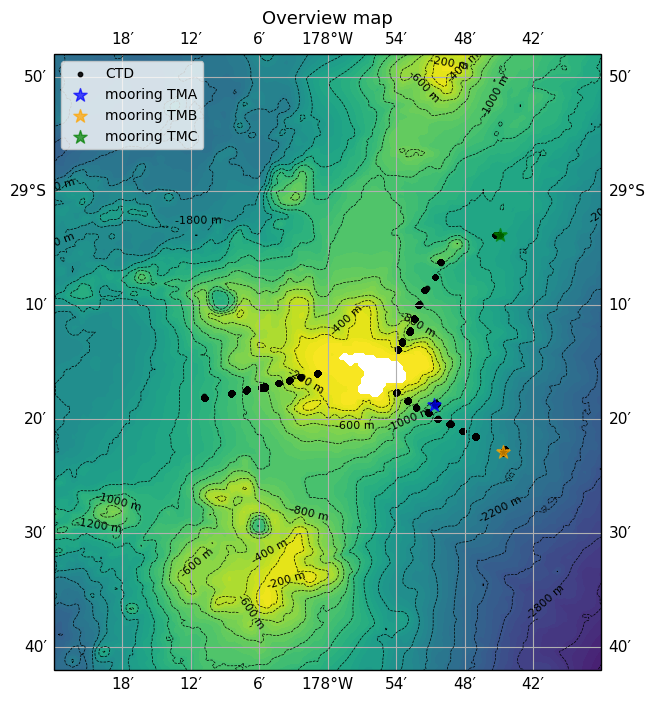

In [51]:
lon_ctd23 = ds_CTD_23.longitude
lat_ctd23 = ds_CTD_23.latitude

lon_ctd24 = ds_CTD_24.longitude
lat_ctd24 = ds_CTD_24.latitude

#lon_glider = ds_glider.longitude
#lat_glider = ds_glider.latitude

# Create figure
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Zoom into the desired region: lon [-179, -178.25], lat [-29.5, -29]
ax.set_extent([-178.4, -177.6, -29.7, -28.8], crs=ccrs.PlateCarree())

# Bathymetry plot
bath = ax.contourf(
    elevation_masked.lon, elevation_masked.lat, elevation_masked,
    levels=np.linspace(-3500, 0, 61),
    cmap='viridis', vmin=-3500, vmax=0,
    transform=ccrs.PlateCarree()
)



# Add land, coastlines, and gridlines
#ax.add_feature(cfeature.LAND, facecolor='lightgray')
#ax.add_feature(cfeature.COASTLINE)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Plot data points
ax.scatter(lon_ctd23, lat_ctd23, color='black', label='CTD', s=10, alpha=0.9)
#ax.scatter(lon_ctd24, lat_ctd24, color='black', s=10, alpha=0.9)
#ax.scatter(lon_glider, lat_glider, color='purple', label='Glider', s=2, alpha=0.7)
ax.scatter(-177.84402, -29.3127, color='blue', label='mooring TMA', s=100, marker='*', alpha=0.7)
ax.scatter( -177.7436, -29.3810, color='orange', label='mooring TMB', s=100,  marker='*', alpha=0.7)
ax.scatter( -177.74858, -29.0641, color='green', label='mooring TMC', s=100,  marker='*', alpha=0.7)


# Add contour lines
contours = ax.contour(
    elevation_masked.lon, elevation_masked.lat, elevation_masked,
    levels=np.arange(-4000, 0+200, 200),  # contour lines every 500 m
    colors='black', linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# Optional: add labels to contours
ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')

# Add legend
plt.legend()
plt.title("Overview map")
plt.savefig('internaltidezoom.png', bbox_inches='tight', dpi=100)
plt.show()


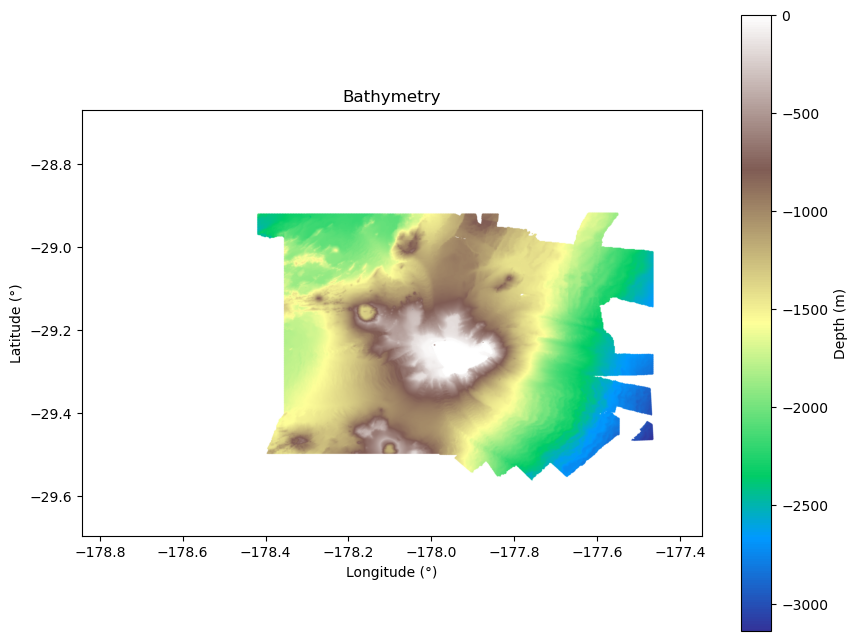

In [25]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import numpy as np
import matplotlib.pyplot as plt
import rasterio

fname = r"C:\Users\rkoe799\Documents\PhD\DATA\bath\bath_raoul\Elevation1.tif"

with rasterio.open(fname) as src:

    transform, width, height = calculate_default_transform(
        src.crs,
        "EPSG:4326",
        src.width,
        src.height,
        *src.bounds
    )

    bathy = np.empty((height, width), dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=bathy,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs="EPSG:4326",
        resampling=Resampling.bilinear
    )

bounds = array_bounds(height, width, transform)

plt.figure(figsize=(10, 8))

img = plt.imshow(
    bathy,
    extent=[bounds[0], bounds[2], bounds[1], bounds[3]],
    origin="upper",
    cmap="terrain",
    vmin=-3140,
    vmax=0
)
ax.contour(
    lon_mbes,
    lat_mbes,
    bathy,
    levels=[0],
    colors='black',
    linewidths=1.5,
    zorder=10
)

plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.colorbar(img, label="Depth (m)")
plt.title("Bathymetry")
plt.show()

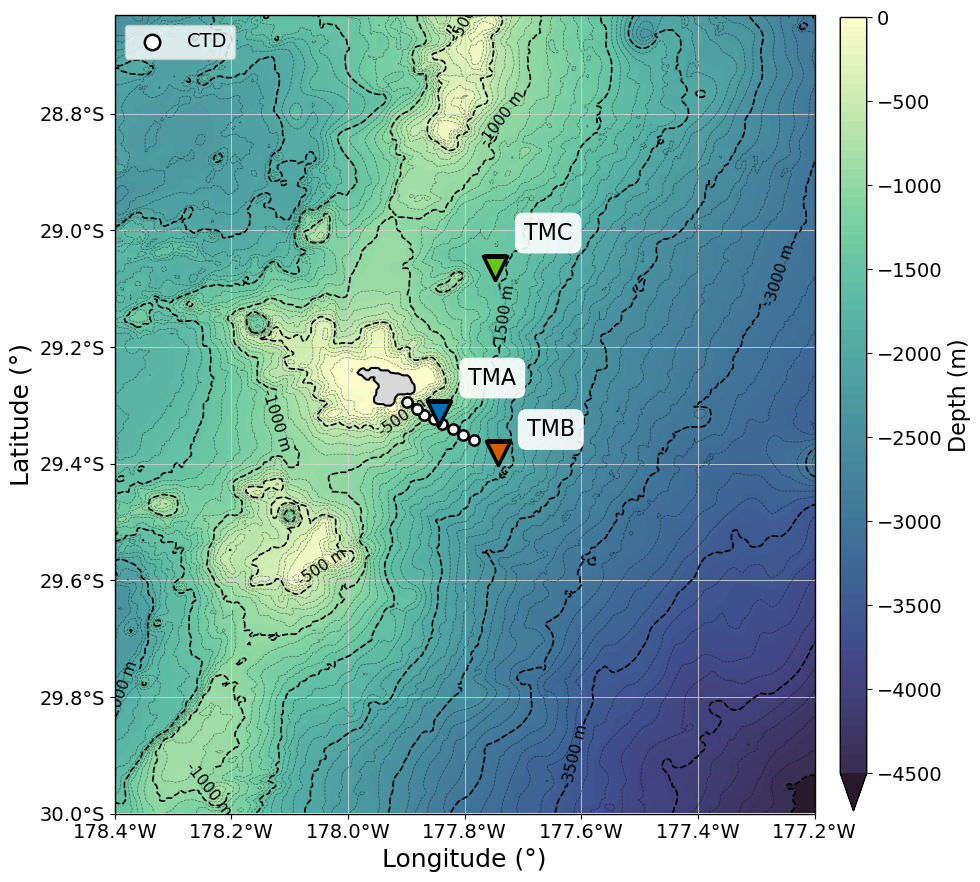

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean

from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# =====================
# LOAD CTD DATA
# =====================

df_ctd = pd.read_csv(
    r"C:\Users\rkoe799\Documents\PhD\CTD\df\df_23_clean_trans_mooring.csv"
)

df_surface = (
    df_ctd.groupby("cast")
    .first()
    .reset_index()
)

df_surface = df_surface[df_surface["transect"] == "SE"]

lon_ctd23 = df_surface["longitude_deg"].values
lat_ctd23 = df_surface["latitude_deg"].values

# =====================
# FIGURE
# =====================

fig = plt.figure(figsize=(10, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# Extended further southeast
ax.set_extent([-178.4, -177.2, -30.0, -28.8])

# =====================
# BATHYMETRY
# =====================

bath = ax.contourf(
    elevation_masked.lon,
    elevation_masked.lat,
    elevation_masked,
    levels=np.linspace(-4500, 0, 81),
    cmap=cmocean.cm.deep_r,
    vmin=-5000,
    vmax=0,
    extend="min"
)

# =====================
# COAST / ISLAND
# =====================

ax.contourf(
    elevation.lon,
    elevation.lat,
    elevation,
    levels=[0, 5000],
    colors=["0.75"],
    alpha=0.6,
    zorder=5,
)

ax.contour(
    elevation.lon,
    elevation.lat,
    elevation,
    levels=[0],
    colors="black",
    linewidths=1.5,
    zorder=6
)

# =====================
# COLORBAR
# =====================

cbar = plt.colorbar(
    bath,
    ax=ax,
    pad=0.03,
    shrink=0.68,    # shorter
    aspect=30      # width stays the same
)
cbar.set_label(
    "Depth (m)",
    fontsize=16
)

cbar.set_ticks(
    np.arange(-4500, 500, 500)
)

cbar.ax.tick_params(
    labelsize=14
)

# =====================
# GRID / TICKS
# =====================

xticks = np.arange(-178.4, -177.1, 0.2)
yticks = np.arange(-30.0, -28.7, 0.2)

ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

ax.xaxis.set_major_formatter(
    LongitudeFormatter(number_format=".1f")
)
ax.yaxis.set_major_formatter(
    LatitudeFormatter(number_format=".1f")
)

ax.grid(
    True,
    linewidth=0.6,
    color="lightgray"
)

ax.tick_params(labelsize=14)

# =====================
# CTD STATIONS
# =====================

ctd = ax.scatter(
    lon_ctd23,
    lat_ctd23,
    s=55,
    facecolor="white",
    edgecolor="black",
    linewidth=1.8,
    label="CTD",
    zorder=8
)

# =====================
# MOORINGS
# =====================

moorings = {
    "TMA": (-177.84402, -29.3127, "#0072B2"),
    "TMB": (-177.7436,  -29.3810, "#D55E00"),
    "TMC": (-177.74858, -29.0641, "#66CC00"),
}


for name, (lon, lat, color) in moorings.items():

    ax.scatter(
        lon,
        lat,
        marker="v",      # upside-down triangle
        s=300,           # may need larger than circles
        color=color,
        edgecolor="black",
        linewidth=2.5,
        zorder=10
    )

    # default offsets
    dx = 0.05
    dy = 0.04

    # move TMB further right
    if name == "TMB":
        dx = 0.05
        dy = 0.02

    ax.text(
        lon + dx,
        lat + dy,
        name,
        fontsize=16,
        ha="left",
        va="bottom",
        zorder=11,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9,
            boxstyle="round,pad=0.4"
        )
    )

# =====================
# BATHYMETRY CONTOURS
# =====================

levels_100 = np.arange(-4500, 0, 100)

ax.contour(
    elevation_masked.lon,
    elevation_masked.lat,
    elevation_masked,
    levels=levels_100,
    colors="black",
    linewidths=0.5,
    linestyles="dashed",
    alpha=0.5,
)

levels_500 = np.arange(-4500, 500, 500)

contours = ax.contour(
    elevation_masked.lon,
    elevation_masked.lat,
    elevation_masked,
    levels=levels_500,
    colors="black",
    linewidths=1.2
)

ax.clabel(
    contours,
    fmt="%d m",
    fontsize=11,
    inline=True,
    inline_spacing=5
)

# =====================
# AXES LABELS
# =====================

ax.set_xlabel(
    "Longitude (°)",
    fontsize=18
)

ax.set_ylabel(
    "Latitude (°)",
    fontsize=18
)

# =====================
# LEGEND
# =====================

ax.legend(
    loc="upper left",
    fontsize=14,          # was 12
    frameon=True,
    markerscale=1.5       # enlarges symbols in legend
)
# Add white land and coastlines
#ax.add_feature(cfeature.LAND, facecolor='white')
#ax.coastlines()

# =====================
# SAVE
# =====================

plt.tight_layout()

plt.savefig(
    "fig01.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [130]:
ds_A = xr.open_dataset(r"C:\Users\rkoe799\Documents\PhD NZ\DATA\Mooring\Moorings\proc\TMA.nc")
ds_B = xr.open_dataset(r"C:\Users\rkoe799\Documents\PhD NZ\DATA\Mooring\Moorings\proc\TMB.nc")
ds_C = xr.open_dataset(r"C:\Users\rkoe799\Documents\PhD NZ\DATA\Mooring\Moorings\proc\TMC.nc")
ds_A

<xarray.Dataset> Size: 208MB
Dimensions:        (time: 21075, depth: 88)
Coordinates:
  * time           (time) datetime64[ns] 169kB 2023-06-21T13:12:04.059104 ......
  * depth          (depth) float32 352B 3.76 8.76 13.76 ... 428.8 433.8 438.8
Data variables: (12/14)
    E              (time, depth) float64 15MB ...
    N              (time, depth) float64 15MB ...
    V              (time, depth) float64 15MB ...
    ER             (time, depth) float64 15MB ...
    E_amp          (time, depth) float64 15MB ...
    C_amp          (time, depth) float64 15MB ...
    ...             ...
    pitch_deg      (time, depth) float64 15MB ...
    roll_deg       (time, depth) float64 15MB ...
    heading_deg    (time, depth) float64 15MB ...
    temperature_C  (time, depth) float64 15MB ...
    depth_m        (time, depth) float64 15MB ...
    battery        (time, depth) float64 15MB ...
Attributes:
    ADCP_system:  Broadband 76.8 kHz
    file_name:    C:\Users\elmerc\NIWA\Ocean Deployments - Projects\TAN2408_k...

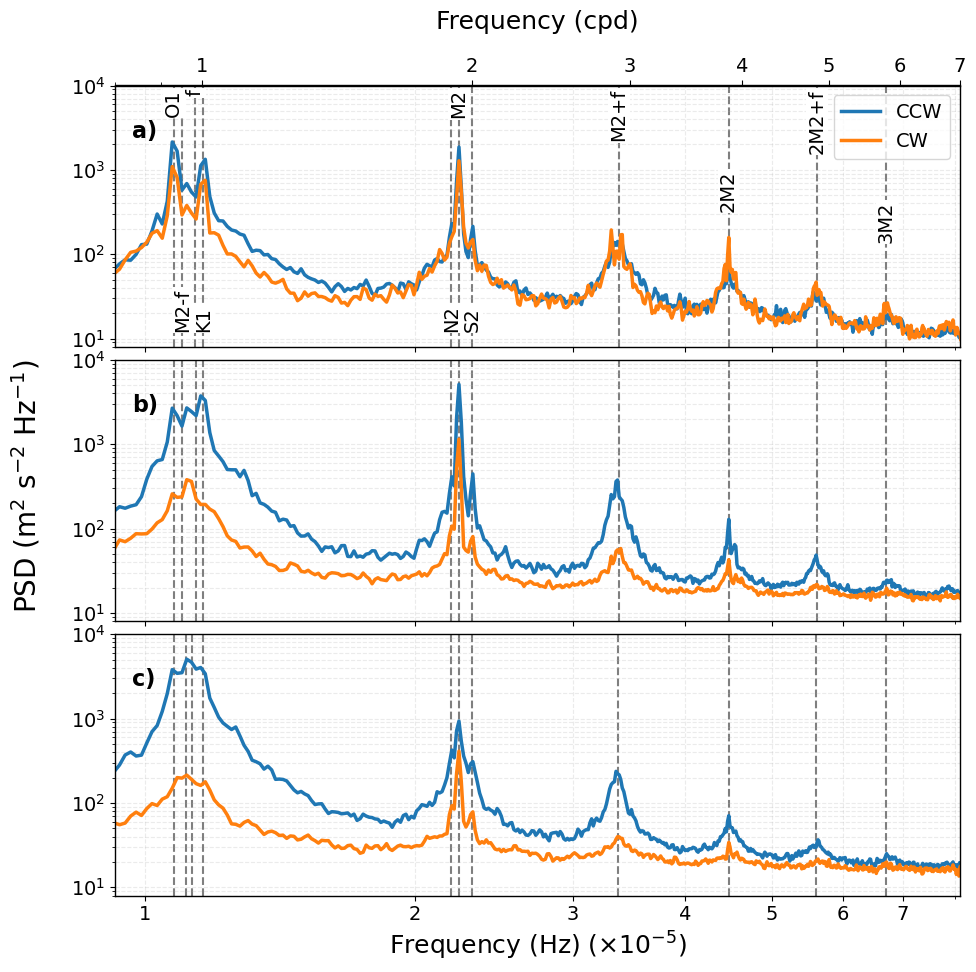

Saved: C:\Users\rkoe799\Documents\PhD\Mooring\results\rotary\Rotary_PSD_ABC_3panel.png


In [195]:
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy.signal import welch

# ============================================================
# SETTINGS
# ============================================================

OUTPUT_DIR = r"C:\Users\rkoe799\Documents\PhD\Mooring\results\rotary"

os.makedirs(OUTPUT_DIR, exist_ok=True)

XMIN_CPD = 0.8
XMAX_CPD = 7

YMIN = 8
YMAX = 1e4

FIG_DPI = 300

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# ============================================================
# CONSTANTS
# ============================================================

Omega = 7.2921159e-5

def inertial_cpd(lat):
    return abs(
        2 * Omega * np.sin(np.deg2rad(lat))
    ) / (2 * np.pi) * 86400

def hz_to_cpd(f):
    return f * 86400

def cpd_to_hz(cpd):
    return cpd / 86400

# ============================================================
# MOORINGS
# ============================================================
# ============================================================
# DATASETS
# ============================================================

datasets = [
    ("a", ds_A, -29.3127),
    ("b", ds_B, -29.3810),
    ("c", ds_C, -29.0641),
]

# ============================================================
# FIGURE
# ============================================================

fig, axs = plt.subplots(
    3, 1,
    figsize=(10, 10),
    sharex=True,
    sharey=True
)

# ============================================================
# LOOP THROUGH MOORINGS
# ============================================================

for i, (ax, (name, ds_combined, SITE_LAT)) in enumerate(
    zip(axs, datasets)
):

    # --------------------------------------------------------
    # FREQUENCY LINES
    # --------------------------------------------------------

    f_cpd = inertial_cpd(SITE_LAT)

    FREQ_LINES = [
        ("O1", 0.9295),
        ("f", f_cpd),
        ("K1", 1.0027),
        ("M2-f", 1.9323 - f_cpd),
        ("N2", 1.89598),
        ("M2", 1.9323),
        ("S2", 2.0),
        ("M2+f", 1.9323 + f_cpd),
        ("2M2", 2 * 1.9323),
        ("2M2+f", 2 * 1.9323 + f_cpd),
        ("3M2", 3 * 1.9323),
    ]

    # --------------------------------------------------------
    # DATA
    # --------------------------------------------------------

    E_bc = ds_combined.E - ds_combined.E.mean("depth")
    N_bc = ds_combined.N - ds_combined.N.mean("depth")

    time = ds_combined.time.values.astype("datetime64[s]")

    dt = np.nanmedian(
        np.diff(time)
    ).astype(float)

    fs = 1.0 / dt

    Sccw_all = []
    Scw_all = []

    # --------------------------------------------------------
    # PSD PER DEPTH
    # --------------------------------------------------------

    for iz in range(ds_combined.depth.size):

        u = E_bc[:, iz].values
        v = N_bc[:, iz].values

        mask = np.isfinite(u) & np.isfinite(v)

        if mask.sum() < 256:
            continue

        u = u[mask]
        v = v[mask]

        z = (u + 1j*v) - np.nanmean(u + 1j*v)

        nperseg = min(len(u)//4, 4096)
        noverlap = int(0.5 * nperseg)

        f, Szz = welch(
            z,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            return_onesided=False
        )

        Sccw = np.zeros_like(Szz)
        Scw = np.zeros_like(Szz)

        Sccw[f > 0] = Szz[f > 0]
        Scw[f < 0] = Szz[f < 0]

        f_pos = f[f > 0]

        Sccw_p = Sccw[f > 0]
        Scw_p = Scw[f < 0][::-1]

        n = min(len(f_pos), len(Scw_p))

        Sccw_all.append(Sccw_p[:n])
        Scw_all.append(Scw_p[:n])

    # --------------------------------------------------------
    # DEPTH AVERAGE
    # --------------------------------------------------------

    Sccw_mean = np.nanmean(Sccw_all, axis=0)
    Scw_mean = np.nanmean(Scw_all, axis=0)

    f_pos = f_pos[:len(Sccw_mean)]

    # --------------------------------------------------------
    # PSD CURVES
    # --------------------------------------------------------

    ax.loglog(
        f_pos,
        Sccw_mean,
        color="tab:blue",
        lw=2.5,
        label="CCW"
    )

    ax.loglog(
        f_pos,
        Scw_mean,
        color="tab:orange",
        lw=2.5,
        label="CW"
    )

    ax.set_ylim(YMIN, YMAX)

    ax.text(
        0.02,
        0.8,
        f"{name})",
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # CONSTITUENT LABEL POSITIONS
    # --------------------------------------------------------

    top_y = YMAX * 0.9
    middle_y1 = YMIN * 70
    middle_y = YMIN * 30
    bottom_y = YMIN * 1.5

    label_position = {
        "O1": "top",
        "f": "top",
        "K1": "bottom",
        "M2-f": "bottom",
        "N2": "bottom",
        "M2": "top",
        "S2": "bottom",
        "M2+f": "top",
        "2M2": "middle1",
        "2M2+f": "top",
        "3M2": "middle",
    }

    # --------------------------------------------------------
    # VERTICAL LINES
    # --------------------------------------------------------

    for constituent, freq_cpd in FREQ_LINES:

        if not (XMIN_CPD <= freq_cpd <= XMAX_CPD):
            continue

        freq_hz = cpd_to_hz(freq_cpd)

        ax.axvline(
            freq_hz,
            color="k",
            linestyle="--",
            alpha=0.5,
            zorder=0
        )

        # labels only on TOP panel

        if i == 0:

            pos = label_position.get(
                constituent,
                "top"
            )

            if pos == "top":
                y = top_y
                va = "top"

            elif pos == "middle1":
                y = middle_y1
                va = "center"

            elif pos == "middle":
                y = middle_y
                va = "center"

            else:
                y = bottom_y
                va = "bottom"

            ax.text(
                freq_hz,
                y,
                constituent,
                rotation=90,
                ha="center",
                va=va,
                fontsize=14,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    pad=1
                ),
                zorder=5
            )

    ax.grid(
        True,
        which="both",
        linestyle="--",
        alpha=0.25
    )

# ============================================================
# SHARED AXES
# ============================================================

for ax in axs:

    ax.set_xlim(
        cpd_to_hz(XMIN_CPD),
        cpd_to_hz(XMAX_CPD)
    )

# ============================================================
# BOTTOM HZ AXIS
# ============================================================

hz_ticks = np.arange(1, 8) * 1e-5

axs[-1].set_xticks(hz_ticks)

axs[-1].set_xticklabels(
    [str(i) for i in range(1, 8)]
)

axs[-1].set_xlabel(
    r"Frequency (Hz) ($\times10^{-5}$)"
)

for ax in axs[:-1]:
    ax.tick_params(
        axis="x",
        labelbottom=False
    )

# ============================================================
# TOP CPD AXIS
# ============================================================

secax = axs[0].secondary_xaxis(
    "top",
    functions=(hz_to_cpd, cpd_to_hz)
)

secax.set_xticks(
    np.arange(1, 8)
)

secax.set_xticklabels(
    [str(i) for i in range(1, 8)]
)

secax.set_xlabel(
    "Frequency (cpd)",
    labelpad=20
)

# ============================================================
# LABELS
# ============================================================

fig.supylabel(
    r"PSD (m$^2$ s$^{-2}$ Hz$^{-1}$)",
    fontsize=20
)

axs[0].legend(
    loc="upper right"
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)

outfile = os.path.join(
    OUTPUT_DIR,
    "Rotary_PSD_ABC_3panel.png"
)

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", outfile)

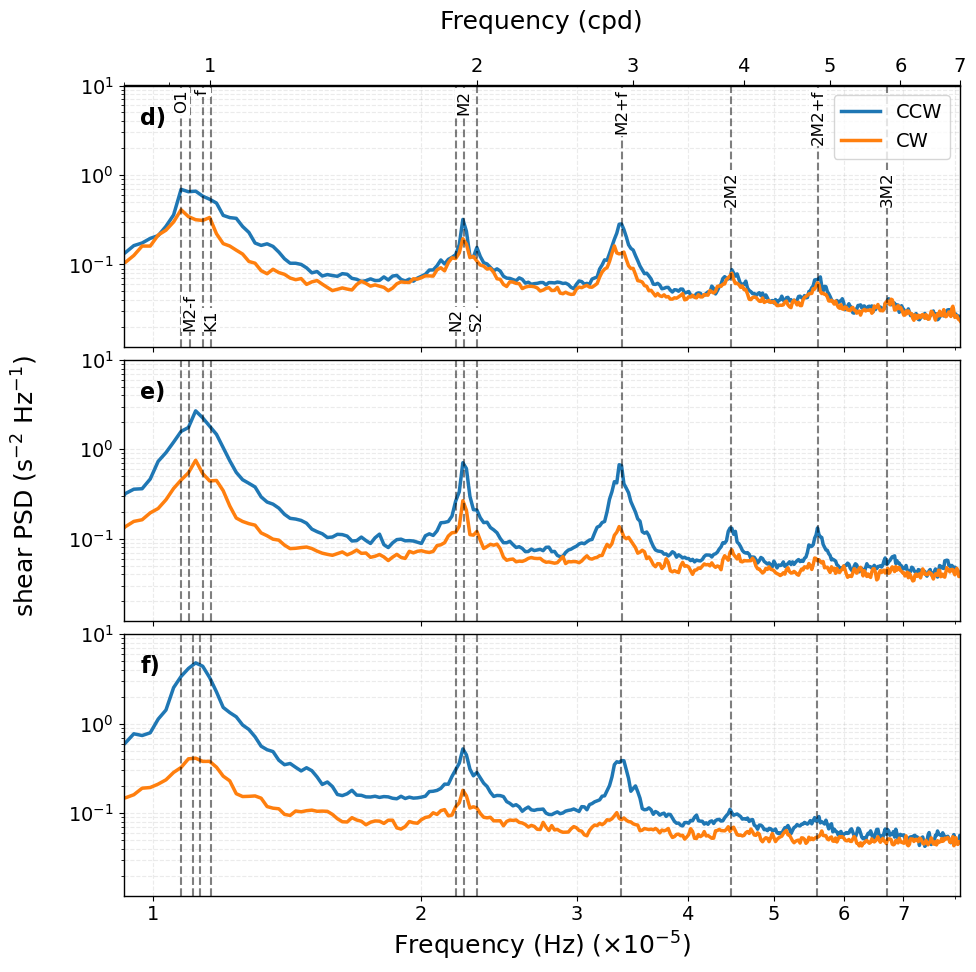

Saved: C:\Users\rkoe799\Documents\PhD\Mooring\results\rotary\Rotary_Shear_PSD_ABC_3panel.png


In [309]:
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy.signal import welch

# ============================================================
# SETTINGS
# ============================================================

OUTPUT_DIR = r"C:\Users\rkoe799\Documents\PhD\Mooring\results\rotary"

os.makedirs(OUTPUT_DIR, exist_ok=True)

XMIN_CPD = 0.8
XMAX_CPD = 7

YMIN = 1.2e-2
YMAX = 1e1

FIG_DPI = 300

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# ============================================================
# CONSTANTS
# ============================================================

Omega = 7.2921159e-5

def inertial_cpd(lat):
    return abs(
        2 * Omega * np.sin(np.deg2rad(lat))
    ) / (2 * np.pi) * 86400

def hz_to_cpd(f):
    return f * 86400

def cpd_to_hz(cpd):
    return cpd / 86400

# ============================================================
# WELCH SETTINGS
# ============================================================

dt_minutes = 30
dt = dt_minutes * 60
fs = 1 / dt

segment_days = 56

nperseg = int(
    segment_days * 24 * 60 /
    dt_minutes
)

# ============================================================
# DATASETS
# ============================================================

datasets = [
    ("a", ds_A, -29.3127),
    ("b", ds_B, -29.3810),
    ("c", ds_C, -29.0641),
]

# ============================================================
# FIGURE
# ============================================================

fig, axs = plt.subplots(
    3, 1,
    figsize=(10,10),
    sharex=True,
    sharey=True
)

# ============================================================
# LOOP THROUGH MOORINGS
# ============================================================

for i, (ax, (name, ds, lat)) in enumerate(
    zip(axs, datasets)
):

    # --------------------------------------------------------
    # BAROCLINIC VELOCITY
    # --------------------------------------------------------

    U_bc = ds.E - ds.E.mean("depth")
    V_bc = ds.N - ds.N.mean("depth")

    # --------------------------------------------------------
    # SHEAR
    # --------------------------------------------------------

    sE = U_bc.differentiate("depth")
    sN = V_bc.differentiate("depth")

    sE = sE.rolling(
        depth=5,
        center=True,
        min_periods=1
    ).mean()

    sN = sN.rolling(
        depth=5,
        center=True,
        min_periods=1
    ).mean()

    # --------------------------------------------------------
    # ROTARY SPECTRA AT ALL DEPTHS
    # --------------------------------------------------------

    Sccw_all = []
    Scw_all = []

    for iz in range(sE.depth.size):

        se = sE[:, iz].values
        sn = sN[:, iz].values

        mask = (
            np.isfinite(se)
            &
            np.isfinite(sn)
        )

        if mask.sum() < nperseg:
            continue

        z = (
            se[mask]
            +
            1j * sn[mask]
        )

        z -= np.nanmean(z)

        f, Szz = welch(
            z,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=nperseg//2,
            detrend="linear",
            return_onesided=False
        )

        f_pos = f[f > 0]

        Sccw = Szz[f > 0]
        Scw = Szz[f < 0][::-1]

        n = min(
            len(Sccw),
            len(Scw)
        )

        Sccw_all.append(
            Sccw[:n]
        )

        Scw_all.append(
            Scw[:n]
        )

    # --------------------------------------------------------
    # DEPTH AVERAGE
    # --------------------------------------------------------

    Sccw_mean = np.nanmean(
        Sccw_all,
        axis=0
    )

    Scw_mean = np.nanmean(
        Scw_all,
        axis=0
    )

    f_pos = f_pos[:len(Sccw_mean)]

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    ax.loglog(
        f_pos,
        Sccw_mean,
        color="tab:blue",
        lw=2.5,
        label="CCW"
    )

    ax.loglog(
        f_pos,
        Scw_mean,
        color="tab:orange",
        lw=2.5,
        label="CW"
    )

    ax.set_ylim(
        YMIN,
        YMAX
    )

    labels = ["d)", "e)", "f)"]

    ax.text(
        0.02,
        0.85,
        labels[i],
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold"
    )
    # --------------------------------------------------------
    # FREQUENCY LINES
    # --------------------------------------------------------

    f_inertial = inertial_cpd(lat)

    FREQ_LINES = [
        ("O1",0.9295),
        ("f",f_inertial),
        ("K1",1.0027),
        ("M2-f",1.9323-f_inertial),
        ("N2",1.89598),
        ("M2",1.9323),
        ("S2",2.0),
        ("M2+f",1.9323+f_inertial),
        ("2M2",2*1.9323),
        ("2M2+f",2*1.9323+f_inertial),
        ("3M2",3*1.9323)
    ]

    top_y = YMAX * 0.9
    mid_y = YMAX * 0.07
    low_y = YMIN * 1.5

    for constituent, fcpd in FREQ_LINES:

        if not (
            XMIN_CPD <= fcpd <= XMAX_CPD
        ):
            continue

        fhz = cpd_to_hz(fcpd)

        ax.axvline(
            fhz,
            color="k",
            ls="--",
            alpha=0.5
        )

        if i == 0:

            if constituent in [
                "O1","f","M2",
                "M2+f","2M2+f"
            ]:
                y = top_y
                va = "top"

            elif constituent in [
                "2M2","3M2"
            ]:
                y = mid_y
                va = "center"

            else:
                y = low_y
                va = "bottom"

            ax.text(
                fhz,
                y,
                constituent,
                rotation=90,
                ha="center",
                va=va,
                fontsize=12,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    pad=1
                )
            )

    ax.grid(
        True,
        which="both",
        ls="--",
        alpha=0.25
    )

# ============================================================
# SHARED AXES
# ============================================================

for ax in axs:

    ax.set_xlim(
        cpd_to_hz(XMIN_CPD),
        cpd_to_hz(XMAX_CPD)
    )

# ============================================================
# BOTTOM HZ AXIS
# ============================================================

hz_ticks = np.arange(1,8) * 1e-5

axs[-1].set_xticks(
    hz_ticks
)

axs[-1].set_xticklabels(
    [str(i) for i in range(1,8)]
)

axs[-1].set_xlabel(
    r"Frequency (Hz) ($\times10^{-5}$)"
)

for ax in axs[:-1]:

    ax.tick_params(
        axis="x",
        labelbottom=False
    )

# ============================================================
# TOP CPD AXIS
# ============================================================

secax = axs[0].secondary_xaxis(
    "top",
    functions=(
        hz_to_cpd,
        cpd_to_hz
    )
)

secax.set_xticks(
    np.arange(1,8)
)

secax.set_xticklabels(
    [str(i) for i in range(1,8)]
)

secax.set_xlabel(
    "Frequency (cpd)",
    labelpad=20
)

# ============================================================
# LABELS
# ============================================================

fig.supylabel(
    r"shear PSD (s$^{-2}$ Hz$^{-1}$)",
    fontsize=18
)

axs[0].legend(
    loc="upper right"
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()
plt.subplots_adjust(
    hspace=0.05
)

outfile = os.path.join(
    OUTPUT_DIR,
    "Rotary_Shear_PSD_ABC_3panel.png"
)

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", outfile)

In [259]:
import xarray as xr
import pandas as pd
import numpy as np

path = r"C:\Users\rkoe799\Documents\PhD\DATA\satellite\clim"

times = pd.date_range(
    "2023-06-01",
    "2024-08-01",
    freq="MS"
)

moorings = [
    {"name": "TMA", "lon": -177.84402, "lat": -29.3127},
    {"name": "TMB", "lon": -177.74360, "lat": -29.3810},
    {"name": "TMC", "lon": -177.74858, "lat": -29.0641},
]

results = {}

for moor in moorings:

    rho_list = []

    for t in times:

        m = t.month

        dsT = xr.open_dataset(
            fr"{path}\woa23_decav_t{m:02d}_04.nc",
            decode_times=False
        )

        dsS = xr.open_dataset(
            fr"{path}\woa23_decav_s{m:02d}_04.nc",
            decode_times=False
        )

        T = (
            dsT["t_an"]
            .squeeze("time")
            .sel(
                lat=moor["lat"],
                lon=moor["lon"],
                method="nearest"
            )
        )

        S = (
            dsS["s_an"]
            .squeeze("time")
            .sel(
                lat=moor["lat"],
                lon=moor["lon"],
                method="nearest"
            )
        )

        rho_list.append(
            xr.Dataset(
                {
                    "temperature": T,
                    "salinity": S
                }
            ).expand_dims(time=[t])
        )

    results[moor["name"]] = xr.concat(
        rho_list,
        dim="time"
    )

import gsw


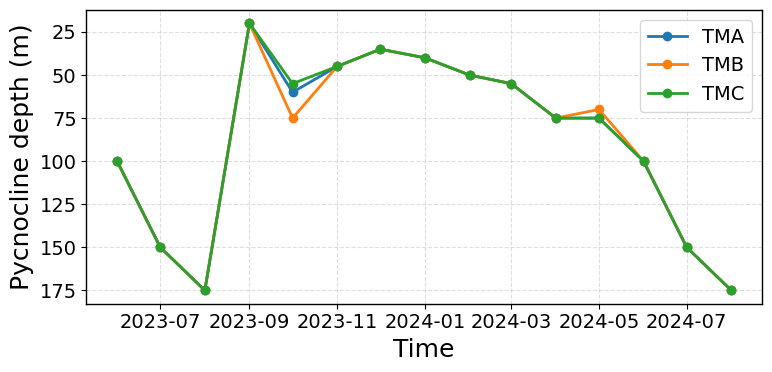

In [278]:
import numpy as np
import xarray as xr
import gsw
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

g = 9.81
rho0 = 1025.0

pyc = {}

for name, ds in results.items():

    depth = ds.depth.values

    if name == "TMA":
        lon, lat = -177.84402, -29.3127
    elif name == "TMB":
        lon, lat = -177.7436, -29.3810
    else:
        lon, lat = -177.74858, -29.0641

    p = gsw.p_from_z(-depth, lat)

    pyc_depth = []

    for it in range(len(ds.time)):

        SP = ds.salinity.isel(time=it).values
        t  = ds.temperature.isel(time=it).values

        SA = gsw.SA_from_SP(
            SP, p,
            lon, lat
        )

        CT = gsw.CT_from_t(
            SA, t, p
        )

        rho = gsw.rho(
            SA, CT, p
        )

        drho_dz = np.gradient(
            rho,
            depth
        )

        N2 = (g / rho0) * drho_dz

    

        # search only between 20 and 200 m
        mask = (
            (depth >= 20)
            &
            (depth <= 300)
        )

        idx_local = np.nanargmax(
            N2[mask]
        )

        idx = np.where(mask)[0][idx_local]

        pyc_depth.append(
            depth[idx]
        )

    pyc[name] = xr.DataArray(
        pyc_depth,
        coords={"time": ds.time},
        dims="time"
    )

# -----------------------------------------------------------
# PLOT
# -----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8,4)
)

for name in ["TMA", "TMB", "TMC"]:

    ax.plot(
        pyc[name].time,
        pyc[name],
        "-o",
        lw=2,
        label=name
    )

ax.invert_yaxis()

ax.set_ylabel(
    "Pycnocline depth (m)"
)

ax.set_xlabel(
    "Time"
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)

ax.legend()

plt.tight_layout()
plt.show()

In [282]:
pyc_interp = {}

for name, ds_moor in zip(
    ["TMA", "TMB", "TMC"],
    [ds_A, ds_B, ds_C]
):

    t_month = pyc[name].time.values.astype("datetime64[s]").astype(float)
    z_month = pyc[name].values

    t_moor = ds_moor.time.values.astype("datetime64[s]").astype(float)

    z_moor = np.interp(
        t_moor,
        t_month,
        z_month
    )

    pyc_interp[name] = xr.DataArray(
        z_moor,
        coords={"time": ds_moor.time},
        dims="time"
    )

In [283]:
for name in pyc_interp:

    print(
        name,
        np.nanmin(pyc_interp[name].values),
        np.nanmax(pyc_interp[name].values)
    )

TMA 20.011172839506173 175.0
TMB 20.006577932098764 175.0
TMC 20.016217206790124 175.0


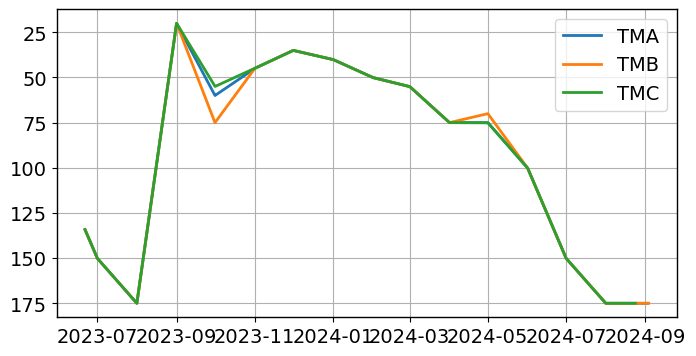

In [284]:
fig, ax = plt.subplots(figsize=(8,4))

for name in ["TMA","TMB","TMC"]:

    ax.plot(
        pyc_interp[name].time,
        pyc_interp[name],
        lw=2,
        label=name
    )

ax.invert_yaxis()
ax.legend()
ax.grid()
plt.show()

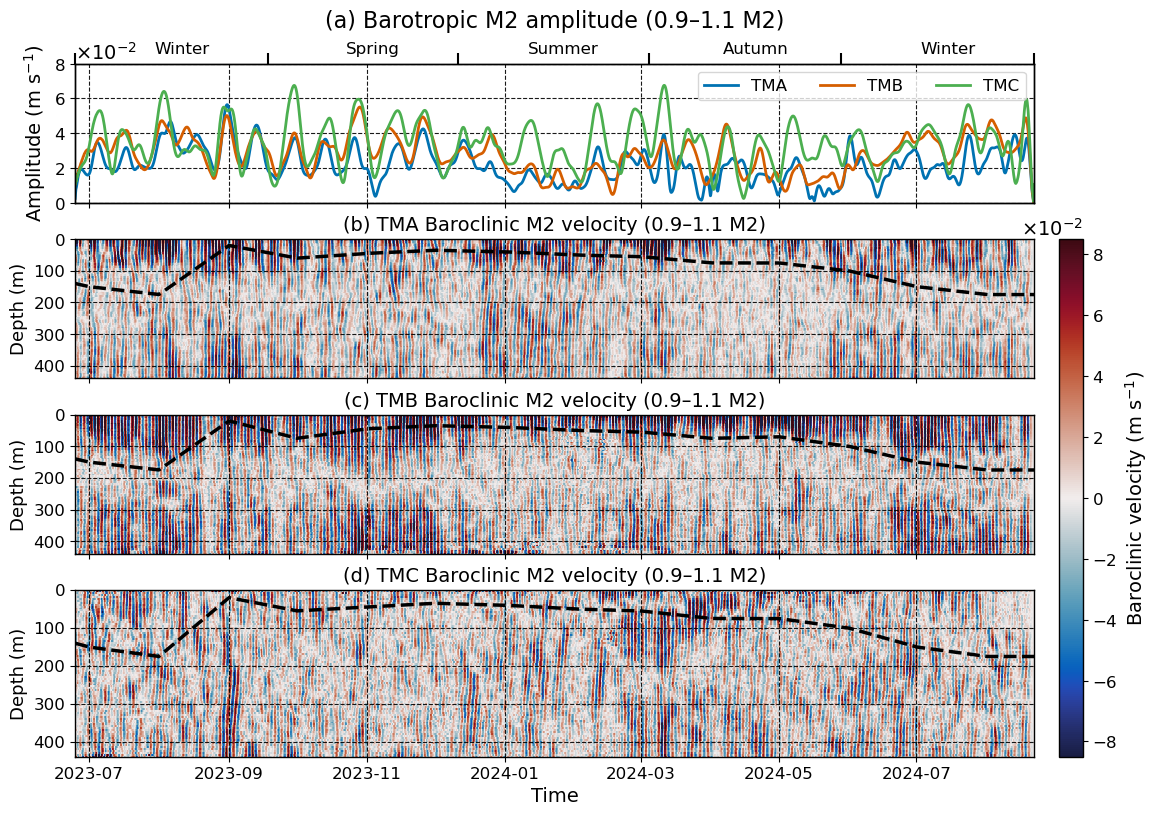

In [334]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
import xarray as xr
import cmocean
from matplotlib.ticker import ScalarFormatter

# ===========================
# ✅ BANDPASS FILTER
# ===========================
def bandpass(data, fs, low, high, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

# ===========================
# ✅ M2 BAND (0.9–1.1)
# ===========================
M2_cpd = 1.9323
low  = 0.9 * M2_cpd / 86400
high = 1.1 * M2_cpd / 86400

# ===========================
# ✅ TIME WINDOW
# ===========================
t_start = "2023-06-25"
t_end   = "2024-08-21"
# ===========================
# ✅ SAMPLING
# ===========================
dt = np.median(np.diff(ds_A.time.values)).astype('timedelta64[s]').astype(float)
fs = 1.0 / dt

# ===========================
# ✅ BATHYMETRY GRADIENT
# ===========================
dy, dx = np.gradient(elevation_masked.values)
norm = np.sqrt(dx**2 + dy**2)
norm[norm == 0] = np.nan
nx = dx / norm
ny = dy / norm

moor_coords = {
    "TMA": (-177.84402, -29.3127),
    "TMB": (-177.7436, -29.3810),
    "TMC": (-177.74858, -29.0641),
}

datasets = {"TMA": ds_A, "TMB": ds_B, "TMC": ds_C}

colors = {
    "TMA": "#0072B2",
    "TMB": "#D55E00",
    "TMC": "#4CAF50"
}

# ===========================
# ✅ FIGURE
# ===========================
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(
    4, 2,
    width_ratios=[1, 0.025],   # slim colorbar
    height_ratios=[1,1,1,1.2],
    hspace=0.25, wspace=0.05
)

ax_top = fig.add_subplot(gs[0, 0])

axes = [
    fig.add_subplot(gs[1, 0], sharex=ax_top),
    fig.add_subplot(gs[2, 0], sharex=ax_top),
    fig.add_subplot(gs[3, 0], sharex=ax_top),
]

cax = fig.add_subplot(gs[1:, 1])

labels = [
    "(b) TMA Baroclinic M2 velocity (0.9–1.1 M2)",
    "(c) TMB Baroclinic M2 velocity (0.9–1.1 M2)",
    "(d) TMC Baroclinic M2 velocity (0.9–1.1 M2)"
]

# ===========================
# ✅ MAIN LOOP
# ===========================
# ===========================
# MAIN LOOP
# ===========================
for i, (name, ds) in enumerate(datasets.items()):

    ds_sub = ds.sel(time=slice(t_start, t_end))

    lon0, lat0 = moor_coords[name]

    ix = np.argmin(np.abs(elevation_masked.lon.values - lon0))
    iy = np.argmin(np.abs(elevation_masked.lat.values - lat0))

    nx0 = np.nanmean(nx[iy-2:iy+3, ix-2:ix+3])
    ny0 = np.nanmean(ny[iy-2:iy+3, ix-2:ix+3])

    # -------------------------
    # VELOCITIES
    # -------------------------
    U = ds_sub["E"].interpolate_na(
        "time",
        method="linear",
        fill_value="extrapolate"
    ).values

    V = ds_sub["N"].interpolate_na(
        "time",
        method="linear",
        fill_value="extrapolate"
    ).values

    t = ds_sub.time.values
    z = ds_sub.depth.values

    # -------------------------
    # CROSS-SLOPE VELOCITY
    # -------------------------
    u = U * nx0 + V * ny0

    # -------------------------
    # BAROTROPIC CURRENT
    # (defined before filtering)
    # -------------------------
    u_bt = np.nanmean(
        u,
        axis=1
    )

    # -------------------------
    # BAROCLINIC CURRENT
    # -------------------------
    u_bc = (
        u
        - u_bt[:, None]
    )

    # -------------------------
    # FILTER EACH COMPONENT
    # -------------------------
    u_bt_f = bandpass(
        u_bt[:, None],
        fs,
        low,
        high
    )[:, 0]

    u_bc_f = bandpass(
        u_bc,
        fs,
        low,
        high
    )

    # -------------------------
    # BAROTROPIC ENVELOPE
    # -------------------------
    u_bt_smooth = xr.DataArray(
        u_bt_f,
        coords={"time": ds_sub.time},
        dims=["time"]
    ).rolling(
        time=12,
        center=True,
        min_periods=1
    ).mean().values

    envelope = np.abs(
        hilbert(u_bt_smooth)
    )

    # -------------------------
    # PLOT FIELD
    # -------------------------
    ax_top.plot(
        t,
        envelope,
        color=colors[name],
        lw=2
    )

    ax = axes[i]

    im = ax.pcolormesh(
        t,
        z,
        u_bc_f.T,
        cmap=cmocean.cm.balance,
        shading="auto",
        vmin=-8.5e-2,
        vmax=8.5e-2
    )

    ax.invert_yaxis()

    ax.set_ylabel(
        "Depth (m)",
        fontsize=13
    )

    ax.set_title(
        labels[i],
        fontsize=14
    )

    ax.set_ylim(
        np.nanmax(z),
        np.nanmin(z)
    )

    ax.set_yticks(
        [0, 100, 200, 300, 400]
    )


# ----------------------------------
    # PYCNOCLINE
    # ----------------------------------


# ✅ FINAL FORMATTING
# ===========================

ax_top.set_ylabel("Amplitude (m s$^{-1}$)", fontsize=14)
fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, -2))

ax_top.set_ylim(0, 0.08)
ax_top.yaxis.set_major_formatter(fmt)
ax_top.set_title(
    "(a) Barotropic M2 amplitude (0.9–1.1 M2)",
    fontsize=16,
    y=1.2
)

ax_top.legend(
    ["TMA", "TMB", "TMC"],
    ncol=3,
    fontsize=12,
    loc="upper right"
)
# ✅ consistent grid across ALL panels
for ax in [ax_top] + axes:
    ax.grid(True,
            linestyle='--',
            linewidth=0.8,
            alpha=0.9,
            color='black', zorder=10)
    

# ✅ remove ONLY top x labels
ax_top.tick_params(axis='x', labelbottom=False)

# ✅ bottom x-axis visible
axes[-1].set_xlabel("Time", fontsize=14)
axes[-1].tick_params(axis='x', labelsize=12)

# ✅ hide middle labels
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

# ✅ tick sizes
for ax in axes:
    ax.tick_params(axis='y', labelsize=12)


xlim = ax.get_xlim()

for ax, name in zip(
    axes,
    ["TMA", "TMB", "TMC"]
):

    ax.plot(
        pyc_interp[name].time,
        pyc_interp[name],
        color="k",
        linestyle="--",
        lw=2.5,
        zorder=21
    )
ax.set_xlim(xlim)

    
ax_top.tick_params(labelsize=12)


# ----------------------------------
# SEASON AXIS ABOVE PANEL ()
# ----------------------------------
# season boundaries
season_edges = [
    np.datetime64("2023-06-01"),
    np.datetime64("2023-09-01"),
    np.datetime64("2023-12-01"),
    np.datetime64("2024-03-01"),
    np.datetime64("2024-06-01"),
    np.datetime64("2024-09-01"),
]

season_labels = ["Winter", "Spring", "Summer", "Autumn", "Winter"]

# top season axis
season_ax = ax_top.twiny()
season_ax.set_xlim(ax_top.get_xlim())

# boundary ticks
season_ax.set_xticks(season_edges)
season_ax.set_xticklabels([])

# put labels centered within each block
for i, label in enumerate(season_labels):

    mid = season_edges[i] + (season_edges[i+1] - season_edges[i]) / 2

    season_ax.text(
        mid + np.timedelta64(5, "D"),
        1.05,
        label,
        transform=season_ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=12,
        #fontweight="bold"
    )

season_ax.tick_params(
    axis='x',
    length=8,
    width=1.5
)
    
# ✅ colorbar
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Baroclinic velocity (m s$^{-1}$)", fontsize=14)
cbar.ax.tick_params(labelsize=12)


formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, -2))

cbar.formatter = formatter
cbar.update_ticks()
plt.show()


Processing TMA
TMA median FBC = 0.63
Processing TMB
TMB median FBC = 0.61
Processing TMC
TMC median FBC = 0.37


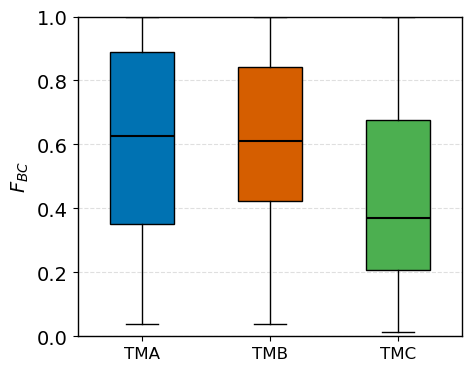

In [338]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# FBC CALCULATION
# ==========================================
FBC = {}

for name, ds in datasets.items():

    print(f"Processing {name}")

    lon0, lat0 = moor_coords[name]

    ix = np.argmin(
        np.abs(elevation_masked.lon.values - lon0)
    )

    iy = np.argmin(
        np.abs(elevation_masked.lat.values - lat0)
    )

    nx0 = np.nanmean(
        nx[iy-2:iy+3, ix-2:ix+3]
    )

    ny0 = np.nanmean(
        ny[iy-2:iy+3, ix-2:ix+3]
    )

    # --------------------------------------
    # INTERPOLATE GAPS
    # --------------------------------------
    U = (
        ds.E
        .interpolate_na("time")
        .fillna(0)
        .values
    )

    V = (
        ds.N
        .interpolate_na("time")
        .fillna(0)
        .values
    )

    # --------------------------------------
    # CROSS-SLOPE VELOCITY
    # --------------------------------------
    u = U * nx0 + V * ny0

    # --------------------------------------
    # BAROTROPIC COMPONENT
    # --------------------------------------
    u_bt = np.nanmean(
        u,
        axis=1
    )

    # --------------------------------------
    # BAROCLINIC COMPONENT
    # --------------------------------------
    u_bc = (
        u
        - u_bt[:, None]
    )

    # --------------------------------------
    # M2 BANDPASS
    # --------------------------------------
    u_bt_f = bandpass(
        u_bt[:, None],
        fs,
        low,
        high
    )[:, 0]

    u_bc_f = bandpass(
        u_bc,
        fs,
        low,
        high
    )

    # --------------------------------------
    # KINETIC ENERGIES
    # Eq. (4)
    # --------------------------------------
    KE_bt = u_bt_f**2

    KE_bc = np.nanmean(
        u_bc_f**2,
        axis=1
    )

    # --------------------------------------
    # BAROCLINIC FRACTION
    # --------------------------------------
    FBC[name] = (
        KE_bc /
        (KE_bc + KE_bt)
    )

    print(
        f"{name} median FBC = "
        f"{np.nanmedian(FBC[name]):.2f}"
    )

# ==========================================
# BOXPLOT
# ==========================================
fig, ax = plt.subplots(
    figsize=(5, 4)
)

bp = ax.boxplot(
    [
        FBC["TMA"],
        FBC["TMB"],
        FBC["TMC"]
    ],
    patch_artist=True,
    widths=0.5,
    showfliers=False,
    medianprops=dict(
        color="black",
        linewidth=1.5
    )
)

colors = [
    "#0072B2",
    "#D55E00",
    "#4CAF50"
]

for patch, color in zip(
    bp["boxes"],
    colors
):
    patch.set_facecolor(color)

ax.set_xticklabels(
    ["TMA", "TMB", "TMC"],
    fontsize=12
)

ax.set_ylabel(
    r"$F_{BC}$",
    fontsize=14
)

ax.set_ylim(0, 1)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

C:\Users\rkoe799\AppData\Local\Temp\ipykernel_26468\2225145039.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


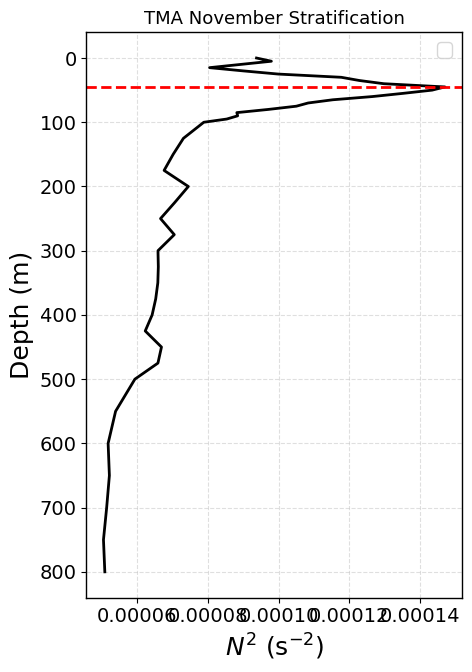

In [314]:
import numpy as np
import gsw
import matplotlib.pyplot as plt

g = 9.81
rho0 = 1025.0

# --------------------------------------------------
# CHOOSE MOORING
# --------------------------------------------------

name = "TMA"

ds = results[name]

lon = -177.84402
lat = -29.3127

depth = ds.depth.values

p = gsw.p_from_z(
    -depth,
    lat
)

# --------------------------------------------------
# NOVEMBER PROFILE
# --------------------------------------------------

itime = np.where(
    ds.time.dt.month ==11
)[0][0]

SP = ds.salinity.isel(time=itime).values
T  = ds.temperature.isel(time=itime).values

SA = gsw.SA_from_SP(
    SP, p,
    lon, lat
)

CT = gsw.CT_from_t(
    SA, T, p
)

rho = gsw.rho(
    SA, CT, p
)

drho_dz = np.gradient(
    rho,
    depth
)

N2 = (g / rho0) * drho_dz

# --------------------------------------------------
# PLOT
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(5, 7)
)

ax.plot(
    N2,
    depth,
    color="k",
    lw=2
)

idx = np.nanargmax(N2)

ax.axhline(
    depth[idx],
    color="red",
    lw=2,
    linestyle="--",
    
)

ax.invert_yaxis()

ax.set_xlabel(
    r"$N^2$ (s$^{-2}$)"
)

ax.set_ylabel(
    "Depth (m)"
)

ax.set_title(
    f"{name} November Stratification"
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)

ax.legend()

plt.tight_layout()
plt.show()

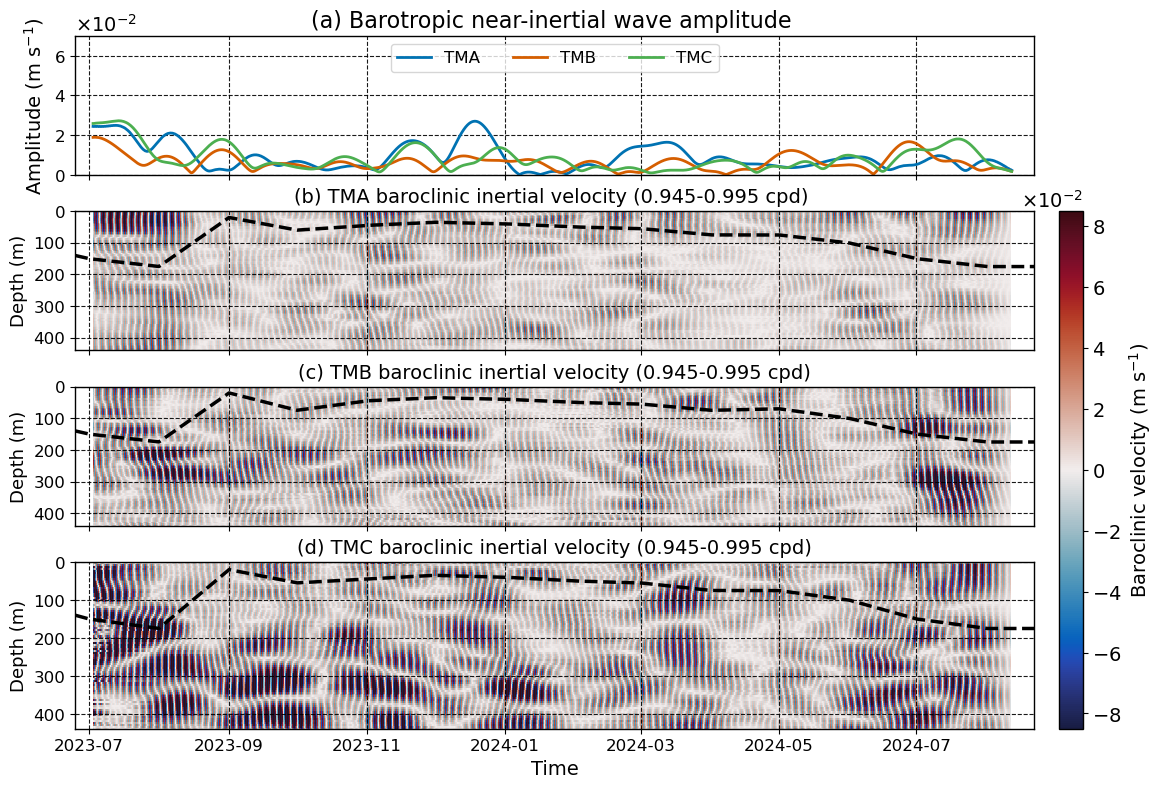

In [298]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
import xarray as xr
import cmocean

# ===========================
# ✅ FUNCTIONS
# ===========================
def bandpass(data, fs, low, high, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

def inertial_cpd(lat):
    Omega = 7.2921159e-5
    f = abs(2 * Omega * np.sin(np.deg2rad(lat)))  # Hz
    return f * 86400   / (2*np.pi)# convert to cpd

# ===========================
# ✅ TIME WINDOW
# ===========================
t_start = "2023-06-23"
t_end   = "2024-08-21"

# ===========================
# ✅ SAMPLING
# ===========================
dt = np.median(np.diff(ds_A.time.values)).astype('timedelta64[s]').astype(float)
fs = 1.0 / dt

# ===========================
# ✅ BATHYMETRY GRADIENT
# ===========================
dy, dx = np.gradient(elevation_masked.values)
norm = np.sqrt(dx**2 + dy**2)
norm[norm == 0] = np.nan
nx = dx / norm
ny = dy / norm

moor_coords = {
    "TMA": (-177.84402, -29.3127),
    "TMB": (-177.7436, -29.3810),
    "TMC": (-177.74858, -29.0641),
}

datasets = {"TMA": ds_A, "TMB": ds_B, "TMC": ds_C}

colors = {
    "TMA": "#0072B2",
    "TMB": "#D55E00",
    "TMC": "#4CAF50"
}

# ===========================
# ✅ FIGURE
# ===========================
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(
    4, 2,
    width_ratios=[1, 0.025],
    height_ratios=[1,1,1,1.2],
    hspace=0.25, wspace=0.05
)

ax_top = fig.add_subplot(gs[0, 0])

axes = [
    fig.add_subplot(gs[1, 0], sharex=ax_top),
    fig.add_subplot(gs[2, 0], sharex=ax_top),
    fig.add_subplot(gs[3, 0], sharex=ax_top),
]

cax = fig.add_subplot(gs[1:, 1])

labels = [
    "(b) TMA baroclinic inertial velocity (0.945-0.995 cpd) ",
    "(c) TMB baroclinic inertial velocity (0.945-0.995 cpd)",
    "(d) TMC baroclinic inertial velocity (0.945-0.995 cpd)"
]
# ===========================# MAIN LOOP
# ===========================
all_env = []

for i, (name, ds) in enumerate(datasets.items()):

    ds_sub = ds.sel(time=slice(t_start, t_end))

    lon0, lat0 = moor_coords[name]

    ix = np.argmin(np.abs(elevation_masked.lon.values - lon0))
    iy = np.argmin(np.abs(elevation_masked.lat.values - lat0))

    nx0 = np.nanmean(nx[iy-2:iy+3, ix-2:ix+3])
    ny0 = np.nanmean(ny[iy-2:iy+3, ix-2:ix+3])

    # ===========================
    # INERTIAL BAND
    # ===========================
    f_cpd = inertial_cpd(lat0)

    low  = 0.945 / 86400
    high = 0.995 / 86400

    # ===========================
    # VELOCITIES
    # ===========================
    U = ds_sub['E'].interpolate_na(
        "time",
        method="linear",
        fill_value="extrapolate"
    ).values

    V = ds_sub['N'].interpolate_na(
        "time",
        method="linear",
        fill_value="extrapolate"
    ).values

    # ===========================
    # CROSS-SLOPE VELOCITY
    # ===========================
    u = U * nx0 + V * ny0

    # ===========================
    # BAROTROPIC CURRENT
    # ===========================
    u_bt = np.nanmean(
        u,
        axis=1
    )

    # ===========================
    # BAROCLINIC CURRENT
    # ===========================
    u_bc = (
        u
        - u_bt[:, None]
    )

    



    # ===========================
    # FILTER EACH COMPONENT
    # ===========================
    u_bt_f = bandpass(
        u_bt[:, None],
        fs,
        low,
        high
    )[:, 0]

    u_bc_f = bandpass(
        u_bc,
        fs,
        low,
        high
    )

    # ===========================
    # BAROTROPIC AMPLITUDE
    # ===========================
    envelope = np.abs(
        hilbert(u_bt_f)
    )
    
   
    ntrim = 96*5
    envelope[:ntrim] = np.nan
    envelope[-ntrim:] = np.nan

    u_bt_f[:ntrim] = np.nan
    u_bt_f[-ntrim:] = np.nan

    u_bc_f[:ntrim, :] = np.nan
    u_bc_f[-ntrim:, :] = np.nan

    envelope = xr.DataArray(
        envelope,
        coords={"time": ds_sub.time},
        dims=["time"]
    ).rolling(
        time=12,          # ~2 days if hourly sampling
        center=True,
        min_periods=1
    ).mean().values

    all_env.append(envelope)



    # ===========================
    # PLOT TOP PANEL
    # ===========================
    t = ds_sub.time.values
    z = ds_sub.depth.values

    ax_top.plot(
        t,
        envelope,
        color=colors[name],
        lw=2,
        
    )

    # ===========================
    # PLOT BAROCLINIC FIELD
    # ===========================
    ax = axes[i]

    im = ax.pcolormesh(
        t,
        z,
        u_bc_f.T,
        cmap=cmocean.cm.balance,
        shading='auto',
        vmin=-8.5e-2,
        vmax=8.5e-2
    )

    ax.invert_yaxis()

    ax.set_ylabel(
        "Depth (m)",
        fontsize=13
    )

    ax.set_title(
        labels[i],
        fontsize=14
    )

    ax.set_ylim(
        np.nanmax(z),
        np.nanmin(z)
    )

    ax.set_yticks(
        [0, 100, 200, 300, 400]
    )

# ===========================
# AUTO Y-LIMITS
# ===========================
ymax = 1.1 * np.nanmax(
    np.concatenate(all_env)
)

ax_top.set_ylim(0, 0.08)
fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, -2))

ax_top.yaxis.set_major_formatter(fmt)
# ===========================
# ✅ FINAL FORMATTING
# ===========================

ax_top.set_ylabel("Amplitude (m s$^{-1}$)", fontsize=14)
ax_top.set_title("(a) Barotropic near-inertial wave amplitude ", fontsize=16)
ax_top.legend(
    ["TMA", "TMB", "TMC"],
    ncol=3,
    loc="upper center",
    frameon=True,
    fontsize=12
)
for ax in [ax_top] + axes:
    ax.grid(True,
            linestyle='--',
            linewidth=0.8,
            alpha=0.9,
            color='black', zorder=10)

ax_top.tick_params(axis='x', labelbottom=False)

axes[-1].set_xlabel("Time", fontsize=14)
axes[-1].tick_params(axis='x', labelsize=12)

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

for ax in axes:
    ax.tick_params(axis='y', labelsize=12)

ax_top.tick_params(labelsize=12)
ax_top.plot(
    t,
    envelope * 100,
    color=colors[name],
    lw=2
)

for ax, name in zip(
    axes,
    ["TMA", "TMB", "TMC"]
):

    ax.plot(
        pyc_interp[name].time,
        pyc_interp[name],
        color="k",
        linestyle="--",
        lw=2.5,
        zorder=21
    )
ax.set_xlim(xlim)


ax_top.set_ylim(0, 0.07)
# ✅ colorbar
cbar = fig.colorbar(im, cax=cax)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, -2))

cbar.formatter = fmt
cbar.update_ticks()

cbar.set_label(
    "Baroclinic velocity (m s$^{-1}$)",
    fontsize=14
)


plt.show()

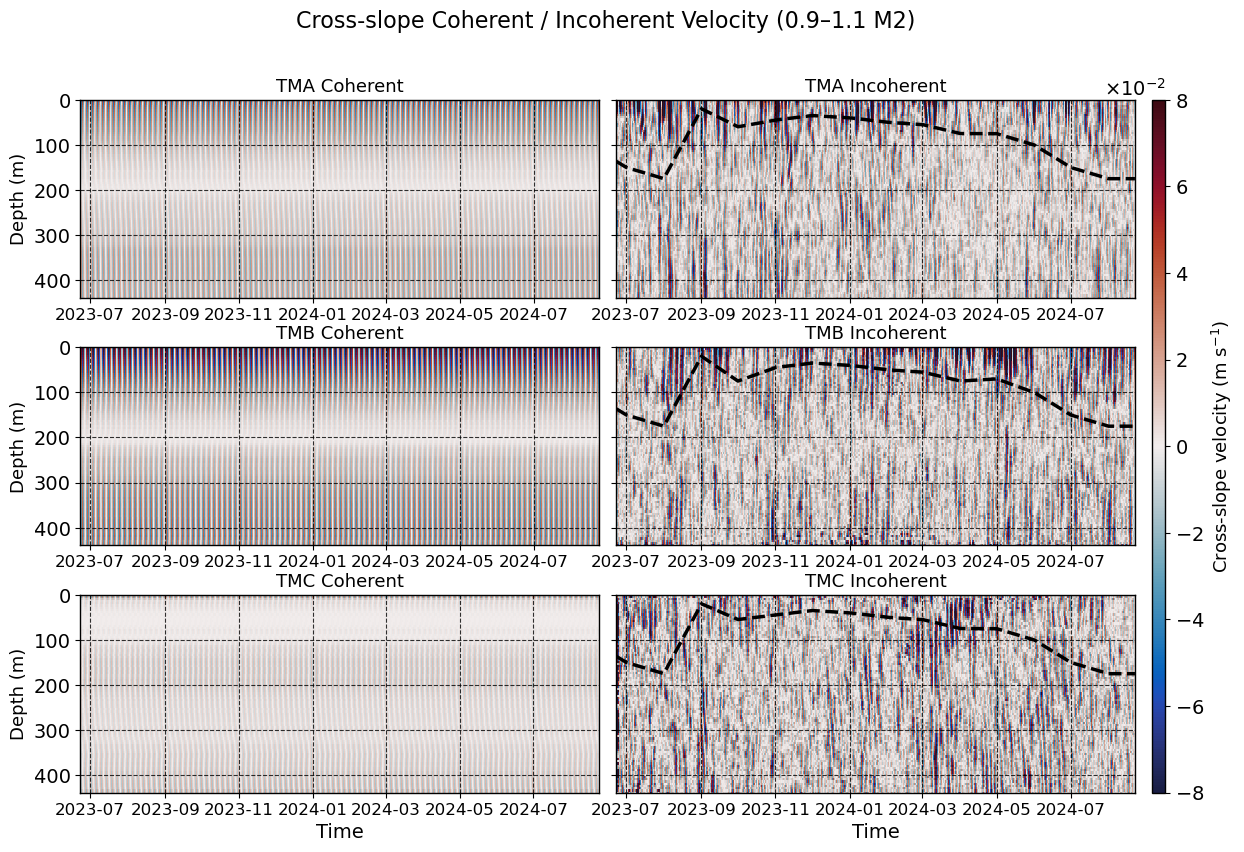

In [308]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from matplotlib.ticker import ScalarFormatter
import cmocean

# ===========================
# SETTINGS
# ===========================

datasets = {
    "TMA": ds_A,
    "TMB": ds_B,
    "TMC": ds_C
}

moor_coords = {
    "TMA": (-177.84402, -29.3127),
    "TMB": (-177.7436, -29.3810),
    "TMC": (-177.74858, -29.0641),
}

M2 = 1.9323

low  = 0.9 * M2 / 86400
high = 1.1 * M2 / 86400

t_start = "2023-06-23"
t_end   = "2024-08-23"

# ===========================
# BANDPASS FILTER
# ===========================

def bandpass(data, fs, low, high, order=4):

    nyq = 0.5 * fs

    b, a = butter(
        order,
        [low/nyq, high/nyq],
        btype="band"
    )

    return filtfilt(
        b,
        a,
        data,
        axis=0
    )

# ===========================
# BATHYMETRY NORMAL VECTOR
# ===========================

dy, dx = np.gradient(
    elevation_masked.values
)

norm = np.sqrt(dx**2 + dy**2)

norm[norm == 0] = np.nan

nx = dx / norm
ny = dy / norm

# ===========================
# SAMPLING
# ===========================

dt = np.median(
    np.diff(ds_A.time.values)
).astype("timedelta64[s]").astype(float)

fs = 1.0 / dt

# ===========================
# COHERENT / INCOHERENT
# ===========================

def compute_coh_inc(u, time):

    u_bc = u - np.nanmean(
        u,
        axis=1,
        keepdims=True
    )

    t = (
        time - time[0]
    ).astype('timedelta64[s]').astype(float)

    omega = 2*np.pi*M2/86400

    G = np.vstack([
        np.cos(omega*t),
        np.sin(omega*t)
    ]).T

    u_coh = np.zeros_like(u_bc)

    for k in range(u_bc.shape[1]):

        coef, *_ = np.linalg.lstsq(
            G,
            u_bc[:, k],
            rcond=None
        )

        u_coh[:, k] = G @ coef

    u_inc = u_bc - u_coh

    return u_coh, u_inc

# ===========================
# FIGURE
# ===========================

fig = plt.figure(figsize=(14, 9))

gs = fig.add_gridspec(
    3, 3,
    width_ratios=[1, 1, 0.025],
    height_ratios=[1, 1, 1],
    hspace=0.25,
    wspace=0.05
)

axes_left  = []
axes_right = []

for i in range(3):

    axes_left.append(
        fig.add_subplot(gs[i, 0])
    )

    axes_right.append(
        fig.add_subplot(
            gs[i, 1],
            sharey=axes_left[i]
        )
    )

cax = fig.add_subplot(gs[:, 2])

# ===========================
# MAIN LOOP
# ===========================

for i, (name, ds) in enumerate(
    datasets.items()
):

    ds = ds.sel(
        time=slice(
            t_start,
            t_end
        )
    )

    lon0, lat0 = moor_coords[name]

    ix = np.argmin(
        np.abs(
            elevation_masked.lon.values
            - lon0
        )
    )

    iy = np.argmin(
        np.abs(
            elevation_masked.lat.values
            - lat0
        )
    )

    nx0 = np.nanmean(
        nx[iy-2:iy+3, ix-2:ix+3]
    )

    ny0 = np.nanmean(
        ny[iy-2:iy+3, ix-2:ix+3]
    )

    U = ds.E.interpolate_na(
        "time",
        fill_value="extrapolate"
    )

    V = ds.N.interpolate_na(
        "time",
        fill_value="extrapolate"
    )

    Uf = bandpass(
        U.values,
        fs,
        low,
        high
    )

    Vf = bandpass(
        V.values,
        fs,
        low,
        high
    )

    # ----------------------------------
    # CROSS-SLOPE VELOCITY
    # ----------------------------------

    u = Uf * nx0 + Vf * ny0

    u_coh, u_inc = compute_coh_inc(
        u,
        ds.time.values
    )

    t = ds.time.values
    z = ds.depth.values

    # ----------------------------------
    # COHERENT
    # ----------------------------------

    ax = axes_left[i]

    im = ax.pcolormesh(
        t,
        z,
        u_coh.T,
        cmap=cmocean.cm.balance,
        shading="auto",
        vmin=-0.08,
        vmax=0.08
    )

    ax.set_title(
        f"{name} Coherent"
    )

    ax.set_ylabel(
        "Depth (m)",
        fontsize=13
    )

    ax.invert_yaxis()

    # ----------------------------------
    # INCOHERENT
    # ----------------------------------

    axr = axes_right[i]

    axr.pcolormesh(
        t,
        z,
        u_inc.T,
        cmap=cmocean.cm.balance,
        shading="auto",
        vmin=-0.08,
        vmax=0.08
    )

    axr.set_title(
        f"{name} Incoherent"
    )

    axr.tick_params(
        labelleft=False
    )

    # ----------------------------------
    # GRID
    # ----------------------------------

    # ----------------------------------
    # PYCNOCLINE
    # ----------------------------------

    # ----------------------------------
    # PYCNOCLINE
    # ----------------------------------

    for a in [axr]:

        a.plot(
            pyc_interp[name].time,
            pyc_interp[name],
            color="k",
            linestyle="--",
            lw=2.5,
            zorder=21
        )

        a.set_xlim(
            np.datetime64(t_start),
            np.datetime64(t_end)
        )

    for a in [ax, axr]:

        a.grid(
            True,
            linestyle="--",
            linewidth=0.8,
            alpha=0.8,
            color="black",
            zorder=10
        )

        a.set_ylim(
            np.nanmax(z),
            np.nanmin(z)
        )

        a.set_yticks(
            [0, 100, 200, 300, 400]
        )

        a.tick_params(
            axis='x',
            labelsize=12
        )

        a.tick_params(
            axis='y',
            labelsize=14
        )
# ===========================
# AXES LABELS
# ===========================

axes_left[-1].set_xlabel("Time", fontsize=14)
axes_right[-1].set_xlabel("Time", fontsize=14)

# ===========================
# COLORBAR
# ===========================

cbar = fig.colorbar(
    im,
    cax=cax
)

fmt = ScalarFormatter(
    useMathText=True
)

fmt.set_powerlimits(
    (-2, -2)
)

cbar.formatter = fmt
cbar.update_ticks()

cbar.set_label(
    "Cross-slope velocity (m s$^{-1}$)",
    fontsize=13
)

# ===========================
# TITLE
# ===========================

fig.suptitle(
    "Cross-slope Coherent / Incoherent Velocity (0.9–1.1 M2)",
    fontsize=16
)

plt.show()

<Figure size 700x500 with 0 Axes>

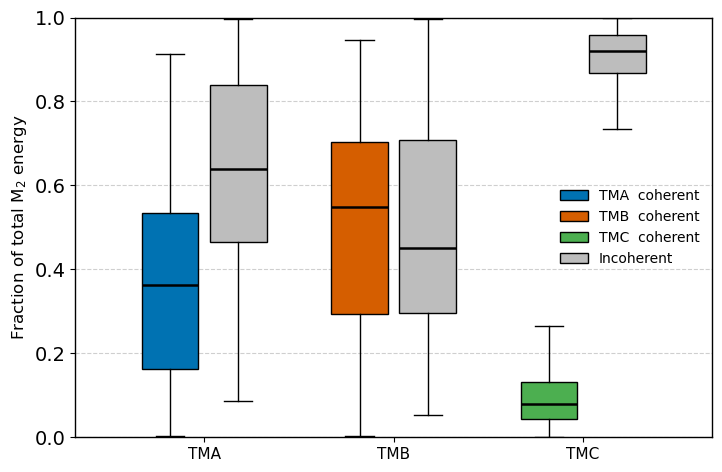

In [304]:
# ===========================
# ✅ BOXPLOT: COHERENT vs INCOHERENT FRACTION
# ===========================

plt.figure(figsize=(7, 5))

data_coh = []
data_inc = []
labels = []

for name, ds in datasets.items():

    ds = ds.sel(time=slice(t_start, t_end))

    lon0, lat0 = moor_coords[name]
    ix = np.argmin(np.abs(elevation_masked.lon.values - lon0))
    iy = np.argmin(np.abs(elevation_masked.lat.values - lat0))

    nx0 = np.nanmean(nx[iy-2:iy+3, ix-2:ix+3])
    ny0 = np.nanmean(ny[iy-2:iy+3, ix-2:ix+3])

    U = ds.E.interpolate_na("time", fill_value="extrapolate")
    V = ds.N.interpolate_na("time", fill_value="extrapolate")

    Uf = bandpass(U.values, fs, low, high)
    Vf = bandpass(V.values, fs, low, high)

    u = Uf*nx0 + Vf*ny0

    # coherent / incoherent
    u_coh, u_inc = compute_coh_inc(u, ds.time.values)

    # depth-averaged energy
    KE_coh = np.nanmean(u_coh**2, axis=1)
    KE_inc = np.nanmean(u_inc**2, axis=1)

    KE_tot = KE_coh + KE_inc

    frac_coh = KE_coh / KE_tot
    frac_inc = KE_inc / KE_tot

    # ✅ mask weak signal (important!)
    amp = np.sqrt(KE_tot)
    thresh = np.nanpercentile(amp, 10)

    mask = amp < thresh
    frac_coh[mask] = np.nan
    frac_inc[mask] = np.nan

    # clean
    frac_coh = frac_coh[np.isfinite(frac_coh)]
    frac_inc = frac_inc[np.isfinite(frac_inc)]

    data_coh.append(frac_coh)
    data_inc.append(frac_inc)
    labels.append(name)

# ===========================
# ✅ PLOT (FINAL CLEAN VERSION)
# ===========================

plt.figure(figsize=(7.5, 5))

positions = np.arange(len(labels))

# coherent
bp1 = plt.boxplot(
    data_coh,
    positions=positions - 0.18,
    widths=0.3,
    patch_artist=True,
    showfliers=False
)

# incoherent
bp2 = plt.boxplot(
    data_inc,
    positions=positions + 0.18,
    widths=0.3,
    patch_artist=True,
    showfliers=False
)

# --- COLORS ---
for patch, name in zip(bp1['boxes'], labels):
    patch.set_facecolor(colors[name])
    patch.set_edgecolor('black')

for patch in bp2['boxes']:
    patch.set_facecolor('#bdbdbd')
    patch.set_edgecolor('black')

# --- MEDIAN STYLE ---
for median in bp1['medians'] + bp2['medians']:
    median.set_color('black')
    median.set_linewidth(1.8)

# ===========================
# ✅ AXES
# ===========================

plt.xticks(positions, labels, fontsize=11)
plt.ylabel("Fraction of total M$_2$ energy", fontsize=12)
#plt.title("Coherent vs Incoherent Energy Fraction (M2)", fontsize=13)

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# ===========================
# ✅ LEGEND (clean + clear)
# ===========================

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=colors["TMA"], edgecolor='black', label='TMA  coherent'),
    Patch(facecolor=colors["TMB"], edgecolor='black', label='TMB  coherent'),
    Patch(facecolor=colors["TMC"], edgecolor='black', label='TMC  coherent'),
    Patch(facecolor='#bdbdbd', edgecolor='black', label='Incoherent'),
]

plt.legend(handles=legend_elements, frameon=False, fontsize=10, loc='center right')

plt.tight_layout()
plt.show()




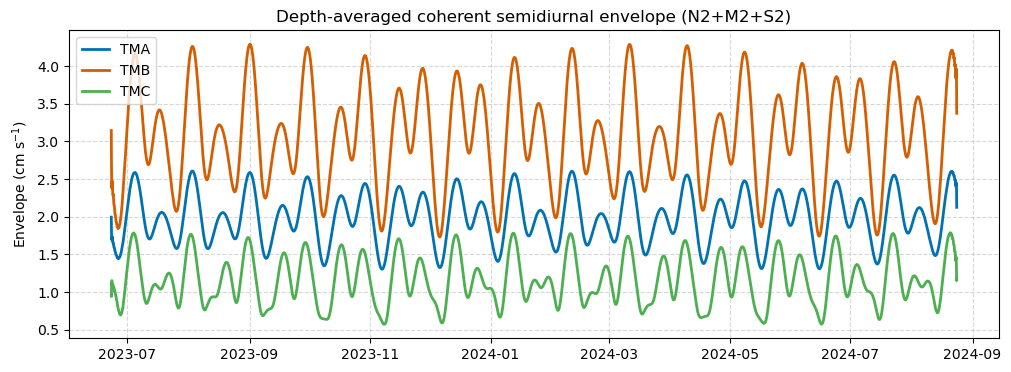

In [207]:
def compute_coh_inc_semidiurnal(u, time):

    u_bc = u - np.nanmean(u, axis=1, keepdims=True)

    t = (time - time[0]).astype('timedelta64[s]').astype(float)

    # ✅ semidiurnal frequencies
    freqs_cpd = [1.89598, 1.9323, 2.0]  # N2, M2, S2

    G_list = []
    for f in freqs_cpd:
        w = 2*np.pi*f/86400
        G_list.append(np.cos(w*t))
        G_list.append(np.sin(w*t))

    G = np.vstack(G_list).T

    u_coh = np.zeros_like(u_bc)

    for k in range(u_bc.shape[1]):
        coef, *_ = np.linalg.lstsq(G, u_bc[:,k], rcond=None)
        u_coh[:,k] = G @ coef

    u_inc = u_bc - u_coh

    return u_coh, u_inc
from scipy.signal import hilbert

# ✅ semidiurnal band
low_sd  = 1.8 / 86400
high_sd = 2.2 / 86400

colors = {
    "TMA": "#0072B2",
    "TMB": "#D55E00",
    "TMC": "#4CAF50"
}

# ===========================
# ✅ COHERENT
# ===========================
plt.figure(figsize=(12,4))

for name, ds in datasets.items():

    ds = ds.sel(time=slice(t_start, t_end))

    lon_vals = elevation_masked.lon.values
    lat_vals = elevation_masked.lat.values

    lon0, lat0 = moor_coords[name]
    ix = np.argmin(np.abs(lon_vals - lon0))
    iy = np.argmin(np.abs(lat_vals - lat0))

    nx0 = np.nanmean(nx[iy-2:iy+3, ix-2:ix+3])
    ny0 = np.nanmean(ny[iy-2:iy+3, ix-2:ix+3])

    U = ds.E.interpolate_na("time", fill_value="extrapolate")
    V = ds.N.interpolate_na("time", fill_value="extrapolate")

    Uf = bandpass(U.values, fs, low_sd, high_sd)
    Vf = bandpass(V.values, fs, low_sd, high_sd)

    u = Uf*nx0 + Vf*ny0

    # ✅ NEW coherent definition
    u_coh, u_inc = compute_coh_inc_semidiurnal(u, ds.time.values)

    env_coh = np.abs(hilbert(u_coh, axis=0))
    env_coh_mean = np.nanmean(env_coh, axis=1)

    plt.plot(ds.time, env_coh_mean*100, color=colors[name], lw=2, label=name)

plt.title("Depth-averaged coherent semidiurnal envelope (N2+M2+S2)")
plt.ylabel("Envelope (cm s$^{-1}$)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()



## internal tides

In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

# === 1. Load the file ===
file_path = r"C:\Users\rensk\OneDrive\Documenten\PhD NZ\DATA\M2_generation_by_mode_corrected.nc"
ds = xr.open_dataset(file_path)


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

# -----------------------------
# 1. Subset domain (dateline-safe)
# -----------------------------
ds_sub = ds.where(
    ((ds.Longitude >= 160) | (ds.Longitude <= -160)) &
    (ds.Latitude >= -60) & (ds.Latitude <= 40),
    drop=True
)

# -----------------------------
# 2. Coarsen for fast plotting
# -----------------------------
# (does NOT change scientific interpretation at basin scale)
ds_sub = ds_sub.coarsen(
    Longitude=2,
    Latitude=2,
    boundary="trim"
).mean()

# -----------------------------
# 3. Total M2 internal tide power
# -----------------------------
M2_total = xr.concat(
    [
        ds_sub.power_mode1,
        ds_sub.power_mode2,
        ds_sub.power_mode3,
        ds_sub.power_mode4,
        ds_sub.power_mode5,
        ds_sub.power_modes6to10,
    ],
    dim="mode",
).sum("mode")

# -----------------------------
# 4. Plot
# -----------------------------
proj = ccrs.PlateCarree(central_longitude=180)

fig, ax = plt.subplots(
    figsize=(18, 7),
    subplot_kw=dict(projection=proj)
)

pcm = ax.pcolormesh(
    ds_sub.Longitude,
    ds_sub.Latitude,
    M2_total,
    cmap=cmocean.cm.tempo,
    vmin=0,
    vmax=0.05,
    shading="auto",
    transform=ccrs.PlateCarree(),
    rasterized=True
)

# Map extent (continuous, dateline-centered)
ax.set_extent([160, 200, -60, 40], crs=ccrs.PlateCarree())

# Coastlines (FAST)
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=3)
ax.coastlines(resolution="110m", linewidth=0.8)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4)
gl.top_labels = False
gl.right_labels = False

# Colorbar
cb = plt.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label("Total M2 internal tide generation (W m$^{-2}$)")

# Title
ax.set_title(
    "Total M2 Internal Tide Generation (Modes 1–10)\n"
    "Southwest Pacific (160°E–160°W, 60°S–40°N)",
    fontsize=13
)

plt.tight_layout()
plt.show()




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


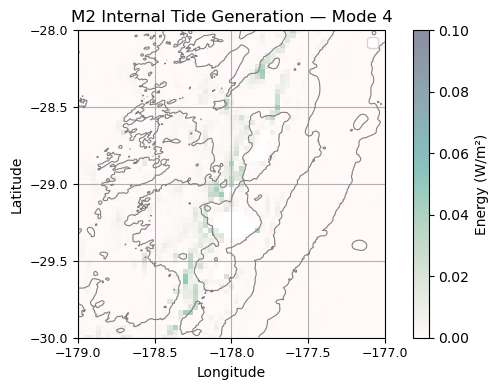

In [38]:

# Assign proper coordinates
ds = ds.assign_coords({
    'Longitude': ds['lon'],
    'Latitude': ds['lat']
})

import numpy as np

# Define region
lon_min, lon_max = -179, -177
lat_min, lat_max = -30, -28

# Subset data for Mode 1
gen_mode1 = ds['power_mode4'].sel(
    Longitude=slice(lon_min, lon_max),
    Latitude=slice(lat_min, lat_max)
)

# Create 2D grid
lon2d, lat2d = np.meshgrid(
    gen_mode1['Longitude'].values,
    gen_mode1['Latitude'].values
)

# Plot
fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': ccrs.PlateCarree()})
# In your pcolormesh call, replace cmap='plasma' with cmap=cmocean.cm.tempo
pcm = ax.pcolormesh(
    lon2d, lat2d, gen_mode1.values,
    cmap=cmocean.cm.tempo,
    shading='auto',
    vmin=0, vmax=0.1, alpha=0.5,
    transform=ccrs.PlateCarree()
)


ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Ticks
ax.set_xticks(np.arange(lon_min, lon_max + 0.5, 0.5), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(lat_min, lat_max + 0.5, 0.5), crs=ccrs.PlateCarree())
ax.tick_params(labelsize=9)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)

# Subset bathymetry
bath_subset = elevation_masked.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
)


# Create 2D grid
lon2d, lat2d = np.meshgrid(bath_subset['lon'], bath_subset['lat'])

# Define bathymetry contour levels
contour_levels = [ -3000, -2000, -1000]

# Create a colormap for contours:
# Use red dashed line for -300 m, gray solid for others
# Create a colormap for contours:
# Use red dashed line for -300 m, gray solid for others
colors = ['grey'] * (len(contour_levels) - 1)
linestyles = ['solid'] * (len(contour_levels) - 1) + ['solid']

# Plot contour lines
contours = ax.contour(
    lon2d, lat2d, bath_subset,
    levels=contour_levels,
    colors=colors,
    linestyles=linestyles,
    linewidths=0.8,
    transform=ccrs.PlateCarree()
)

#labels = ax.clabel(contours, fmt='%d m', fontsize=8, colors='black')


plt.colorbar(pcm, ax=ax, label='Energy (W/m²)')
ax.set_title('M2 Internal Tide Generation — Mode 4', fontsize=12)

plt.grid()
plt.tight_layout()
# Add legend
plt.legend()
plt.savefig('internaltidezoom.png', bbox_inches='tight', dpi=100)
plt.show()
